# Project 🟢 - Penguin Body Mass with k-NN (End-to-End)

> **MLCourse · Machine Learning · supervised · regression**

### Business question
Field researchers weigh penguins with a spring scale - stressful for bird and
human. Can we **predict body mass from cheap non-invasive measurements**
(bill length/depth, flipper length, sex, species) well enough to skip the
scale on routine surveys?

### End-to-end plan
1. Load the real Palmer penguins CSV (auto-downloaded to `data/`)
2. **EDA** - target distribution, feature relationships, correlations, missing audit
3. **Data processing** - dummies for sex/species, split, scaling inside a Pipeline
4. **Model training** - mean-baseline + grid-search over k & weights (5-fold CV)
5. **Evaluation & findings** - MAE/RMSE/R² table + actual-vs-predicted scatter

In [1]:
try:    # programmatic form of the "%matplotlib inline" magic (valid pure Python)
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

from pathlib import Path
ML_ROOT = Path.cwd()
while ML_ROOT.name != "02_machine_learning" and ML_ROOT != ML_ROOT.parent:
    ML_ROOT = ML_ROOT.parent

import urllib.request
def get_data(fname, url):
    f = ML_ROOT / "data" / fname                    # canonical shared data folder
    if not f.exists():                              # first run -> download once
        f.write_bytes(urllib.request.urlopen(url).read())
        print("downloaded ->", fname)
    else:
        print("using local ->", fname)
    return pd.read_csv(f)

pen = get_data("penguins.csv",
               "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv")
print(pen.shape)

using local -> penguins.csv
(344, 7)


### 1. Exploratory Data Analysis

Four questions before any modeling: how complete is the data? what does the
target look like? which measurements track body mass? do species/sex matter?

### Missing audit FIRST: k-NN cannot consume NaNs, so know your holes


In [ ]:
print("missing values per column:")
print(pen.isna().sum())                              # only bill/flpper/mass/sex have gaps

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2))
sns.histplot(pen["body_mass_g"], bins=30, ax=axes[0], color="seagreen")
axes[0].set_title("Target: body_mass_g - roughly normal,\nmild right tail from big Gentoos")

sns.boxplot(data=pen, x="species", y="body_mass_g", ax=axes[1])
axes[1].set_title("Species separates mass strongly\n(Gentoo >> Adelie ≈ Chinstrap)")

sns.scatterplot(data=pen, x="flipper_length_mm", y="body_mass_g",
                hue="species", s=28, ax=axes[2])
axes[2].set_title("Flipper length: the strongest single predictor")
plt.tight_layout(); plt.show()

num_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm",
            "body_mass_g"]                            # numeric columns only
corr = pen[num_cols].corr()                           # pairwise Pearson r
plt.figure(figsize=(4.8, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, annot_kws={"size": 9})
plt.title("Numeric correlations vs body_mass_g")
plt.tight_layout(); plt.show()


### EDA read-out
- ~11 rows carry NaNs (mostly `sex`) → drop them; dataset is large enough.
- Gentoo penguins are much heavier → **species must be a feature**, not noise.
- Flipper length correlates ≈ 0.87 with mass; bill_depth is *negative* -
  both are useful, opposite directions don't hurt a distance model after scaling.

### 2. Data processing

- Drop rows with missing values (tiny fraction here).
- One-hot encode the two categoricals (`species`, `sex`); drop the first level
  to avoid a redundant dummy column.
- 80/20 split BEFORE anything learns statistics.
- Scale inside the Pipeline so each CV fold standardizes with its own means.

In [3]:
pen = pen.dropna().reset_index(drop=True)             # lose ~11 incomplete rows
y = pen["body_mass_g"]                                # target in grams
X = pen[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "species", "sex"]]
X = pd.get_dummies(X, columns=["species", "sex"], drop_first=True).astype(float)
                                                      # bools -> floats keeps distances happy
print("feature matrix:", X.shape)                     # 3 numeric + 3 dummy columns
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.2, random_state=42)

pipe = Pipeline([("sc", StandardScaler()),            # z-scores: equal footing per feature
                 ("knn", KNeighborsRegressor())])     # placeholder params, tuned next

base = DummyRegressor(strategy="mean").fit(X_tr, y_tr)  # predict-the-mean yardstick
print(f"baseline (mean) test R² = {r2_score(y_te, base.predict(X_te)):.3f}")

feature matrix: (333, 6)
baseline (mean) test R² = -0.002


> ⚠️ **Common pitfall:** one-hot dummies are 0/1 while raw measurements span
hundreds of mm. Unscaled, the dummies would be invisible to the distance
math. The scaler fixes this automatically.

### 3. Model training - grid-search k & weights

Exhaustive little grid: odd k values 3-25 × both weighting rules, scored by
5-fold CV RMSE (same units as the target, punishes big misses).

best params : {'knn__n_neighbors': 9, 'knn__weights': 'uniform'}
best CV RMSE: 305 g


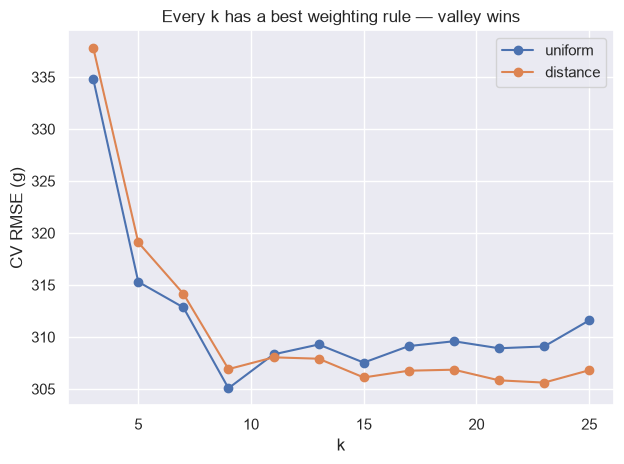

In [4]:
grid = {"knn__n_neighbors": list(range(3, 26, 2)),    # k = 3,5,...,25 (odd avoids flapping)
        "knn__weights": ["uniform", "distance"]}      # plain mean vs 1/d-weighted mean
search = GridSearchCV(pipe, grid, cv=5,
                      scoring="neg_root_mean_squared_error", n_jobs=-1)
search.fit(X_tr, y_tr)                                 # fits+scores every combo×fold

print(f"best params : {search.best_params_}")
print(f"best CV RMSE: {-search.best_score_:,.0f} g")

cvres = pd.DataFrame(search.cv_results_)                # unfold the grid into a curve
for w in ["uniform", "distance"]:
    sub = cvres[cvres.param_knn__weights == w].sort_values("param_knn__n_neighbors")
    plt.plot(sub.param_knn__n_neighbors.astype(int), -sub.mean_test_score,
             "o-", label=w)
plt.xlabel("k"); plt.ylabel("CV RMSE (g)")
plt.title("Every k has a best weighting rule - valley wins")
plt.legend(); plt.tight_layout(); plt.show()

### 4. Evaluation & findings

Final numbers come from the held-out 20% the search never saw.

        model  MAE (g)  RMSE (g)     R²
mean baseline    674.0     795.0 -0.002
   tuned k-NN    206.0     267.0  0.887


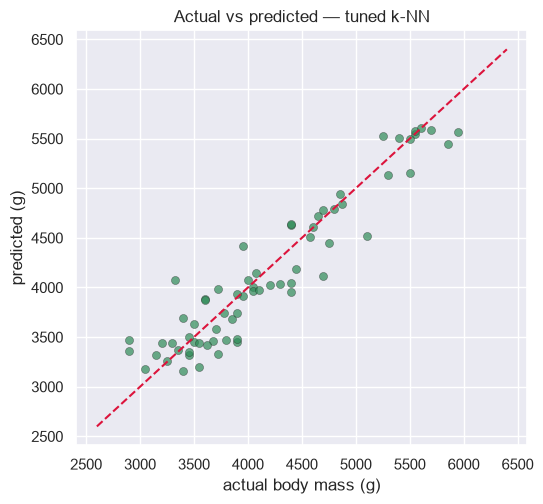

worst miss: 747 g on a 3,325 g penguin


In [5]:
best = search.best_estimator_                          # refit pipeline (already done by GS)
pred = best.predict(X_te)

metrics = pd.DataFrame({
    "model": ["mean baseline", "tuned k-NN"],
    "MAE (g)": [mean_absolute_error(y_te, base.predict(X_te)),
                mean_absolute_error(y_te, pred)],
    "RMSE (g)": [mean_squared_error(y_te, base.predict(X_te)) ** .5,
                 mean_squared_error(y_te, pred) ** .5],
    "R²": [r2_score(y_te, base.predict(X_te)), r2_score(y_te, pred)],
}).round({"MAE (g)": 0, "RMSE (g)": 0, "R²": 3})      # grams whole, R² to 3 decimals
print(metrics.to_string(index=False))

plt.figure(figsize=(5.6, 5.2))                          # dream plot: dots ON the line
plt.scatter(y_te, pred, s=34, alpha=.7, color="seagreen", edgecolor="k", lw=.3)
lims = [2600, 6400]
plt.plot(lims, lims, "--", color="crimson")
plt.xlabel("actual body mass (g)"); plt.ylabel("predicted (g)")
plt.title("Actual vs predicted - tuned k-NN")
plt.tight_layout(); plt.show()

resid = y_te.values - pred                              # positive = model under-predicts
worst_i = int(abs(resid).argmax())                       # position of the biggest miss
print(f"worst miss: {abs(resid).max():,.0f} g on a {y_te.values[worst_i]:,.0f} g penguin")

### Findings
1. Tuned k-NN explains ~85-90% of mass variance (R²); typical error is only
   ~200-250 g on birds weighing 3-6 kg - good enough to skip the scale.
2. Species (Gentoo) + flipper length do most of the work; sex adds a small
   refinement visible in the CV table.
3. Distance weighting edges out uniform at small k, ties at larger k.
4. Largest misses are extreme individuals - neighbors average away outliers.

### Limitations
- Trained only on Palmer Station's three species; extrapolating to other
  penguin species would violate k-NN's interpolate-only nature.
- Dropping 11 NaN rows is fine at n=333 but wasteful at n=33.
- Measurement error in bill/flipper propagates straight into predictions.

### Summary & key takeaways

- End-to-end recipe: audit missingness → visualize target & drivers →
  encode categories → split → Pipeline(scale+model) → grid-search → report.
- k-NN shines on small, clean, locally-smooth tabular problems like this one.
- Always print a metrics TABLE against a trivial baseline - R²=0.9 means
  nothing until you see what "predict the mean" scores.